# Gravitational Wave Templates, Matched Filtering, and Parameter Estimation

## Overview

This notebook continues from `data_tutorial.ipynb`, where we whitened the strain data
and saw the GW signal by eye. Here we move from qualitative detection to **quantitative
analysis**:

1. **Waveform models** — generate theoretical templates in the time and frequency domains,
   and build intuition for how the chirp parameters are encoded in the waveform shape
2. **Matched filtering** — introduce the noise-weighted inner product and develop
   step-by-step intuition for why time alignment is critical for extracting the SNR
3. **Parameter estimation** — set up a short Bayesian PE run with bilby and examine
   the resulting posterior distribution

> **Prerequisites**: Run `data_tutorial.ipynb` first and save the data files, or
> download the data in the Setup cell below.


In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from gwosc.datasets import event_gps
from gwosc.api import fetch_event_json
from gwpy.timeseries import TimeSeries
from pycbc.waveform import get_td_waveform, get_fd_waveform

plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 12})
plt.style.use("seaborn-v0_8-whitegrid")
print("Packages loaded.")


Packages loaded.


In [15]:
# ── Load data (from local files saved in data_tutorial, or re-download) ───────
gps = event_gps('GW250114_082203')
segment = (int(gps) - 16, int(gps) + 16)
event_time_in_segment = 16.0 + (gps - int(gps))

import os
if os.path.exists("GW250114_082203_H1.gwf") and os.path.exists("GW250114_082203_L1.gwf"):
    print("Loading data from local files...")
    hdata = TimeSeries.read("GW250114_082203_H1.gwf")
    ldata = TimeSeries.read("GW250114_082203_L1.gwf")
else:
    print("Downloading data from GWOSC (this may take a minute)...")
    hdata = TimeSeries.fetch_open_data('H1', *segment)
    ldata = TimeSeries.fetch_open_data('L1', *segment)

print(f"GPS time: {gps}")
print(f"H1: {len(hdata)} samples at {1/hdata.dt.value:.0f} Hz")
print(f"Event position in segment: {event_time_in_segment:.3f} s")


GPS time: 1420878141.2
H1: 131072 samples at 4096 Hz
Event position in segment: 16.200 s


In [17]:
# ── Reproduce ASD estimation and whitening from data_tutorial ─────────────────
def bandpass_window(freqs, f_low, f_high, taper_low=10., taper_high=100.):
    w = np.ones_like(freqs)
    ml = (freqs > f_low) & (freqs < f_low + taper_low)
    w[ml] = 0.5 * (1 - np.cos(np.pi * (freqs[ml] - f_low) / taper_low))
    w[freqs <= f_low] = 0.
    mh = (freqs > f_high - taper_high) & (freqs < f_high)
    w[mh] = 0.5 * (1 + np.cos(np.pi * (freqs[mh] - (f_high - taper_high)) / taper_high))
    w[freqs >= f_high] = 0.
    return w

def whiten_bandpass(ts, asd_func, f_low=20, f_high=500, taper_low=10., taper_high=100.):
    N = len(ts); dt = ts.dt.value
    tukey = scipy.signal.windows.tukey(N, alpha=0.1)
    fd = np.fft.rfft(tukey * ts.value)
    freqs = np.fft.rfftfreq(N, d=dt)
    norm = asd_func(freqs) / np.sqrt(2 * dt)
    bp   = bandpass_window(freqs, f_low, f_high, taper_low, taper_high)
    td   = np.fft.irfft(bp * fd / norm, n=N)
    return dt * np.arange(len(td)), td, bp, freqs

asd_h = hdata.asd(fftlength=2., method="median")
asd_l = ldata.asd(fftlength=2., method="median")
asd_h_interp = interp1d(asd_h.frequencies.value, asd_h.value, bounds_error=False, fill_value=np.inf)
asd_l_interp = interp1d(asd_l.frequencies.value, asd_l.value, bounds_error=False, fill_value=np.inf)

times_h, h_wbp, _, _ = whiten_bandpass(hdata, asd_h_interp)
times_l, l_wbp, _, _ = whiten_bandpass(ldata, asd_l_interp)
print("Whitening complete. Ready to proceed.")


Whitening complete. Ready to proceed.


---
## 1. Waveform Models

### The IMR (Inspiral–Merger–Ringdown) framework

A compact binary coalescence produces three distinct phases in its gravitational-wave emission:

| Phase | Description | Timescale |
|-------|-------------|-----------|
| **Inspiral** | The two bodies spiral in, losing energy to GW emission. Frequency and amplitude grow slowly (chirp). | seconds to minutes |
| **Merger** | The two objects plunge together. The waveform reaches peak amplitude. | milliseconds |
| **Ringdown** | The merged remnant oscillates as a perturbed Kerr black hole. The signal decays exponentially. | < 100 ms |

Several families of waveform **approximants** exist, differing in how they model these phases:

- **Phenomenological** (IMRPhenom*): closed-form fits to NR. Fast, flexible. Used in most GWTC analyses.
- **EOB** (SEOB*): based on the effective-one-body Hamiltonian. More physically motivated.
- **NR surrogates** (NRSur7dq4): interpolate directly over NR waveforms. Most accurate but restricted parameter range.

We use `pycbc`'s `get_td_waveform` (time-domain) and `get_fd_waveform` (frequency-domain) to generate templates.


In [18]:
# ── Fetch catalog parameters for GW250114 ─────────────────────────────────────
event_data = fetch_event_json('GW250114_082203')
event_key  = list(event_data['events'].keys())[0]
params     = event_data['events'][event_key]

m1_source = params['mass_1_source']
m2_source = params['mass_2_source']
redshift  = params['redshift']
chi_eff   = params['chi_eff']
dist_mpc  = params['luminosity_distance']

# Convert to detector-frame masses (cosmological redshift stretches the waveform)
m1_det = m1_source * (1.0 + redshift)
m2_det = m2_source * (1.0 + redshift)

print(f"Source-frame:    m1 = {m1_source:.1f}, m2 = {m2_source:.1f} Msun,  z = {redshift:.3f}")
print(f"Detector-frame:  m1 = {m1_det:.1f}, m2 = {m2_det:.1f} Msun  (×(1+z) = {1+redshift:.3f})")
print(f"chi_eff = {chi_eff:.3f},  d_L = {dist_mpc:.0f} Mpc")


Source-frame:    m1 = 33.8, m2 = 32.3 Msun,  z = 0.090
Detector-frame:  m1 = 36.8, m2 = 35.2 Msun  (×(1+z) = 1.090)
chi_eff = -0.030,  d_L = 405 Mpc


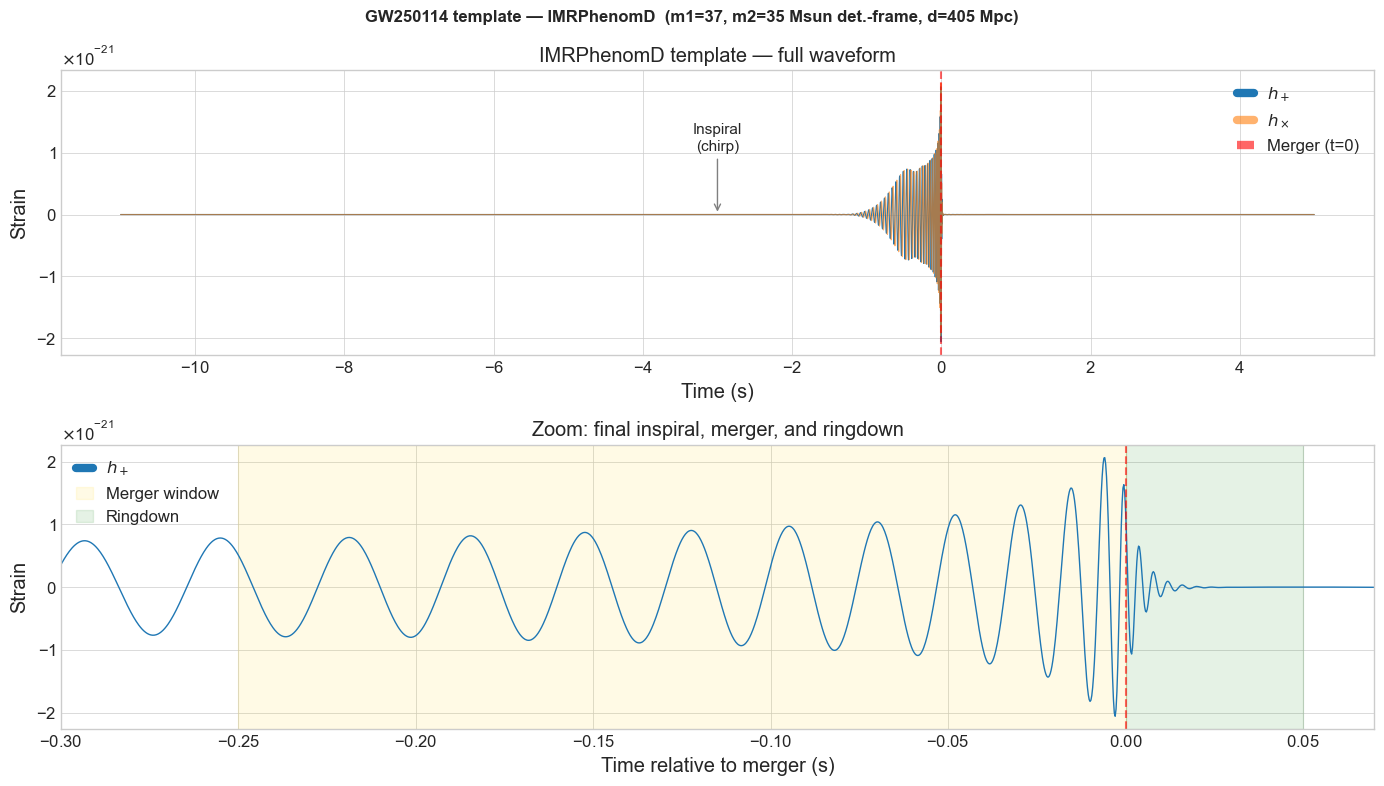

In [19]:
# ── Generate the GW250114 template and show the three IMR phases ───────────────
hp, hc = get_td_waveform(
    approximant="IMRPhenomD",
    mass1=m1_det, mass2=m2_det,
    spin1z=chi_eff, spin2z=chi_eff,
    delta_t=hdata.dt.value, f_lower=20.0, distance=dist_mpc,
)

t = np.array(hp.sample_times)    # merger at t = 0

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Top: full waveform ────────────────────────────────────────────────────────
axes[0].plot(t, hp, color='C0', lw=0.8, label=r'$h_+$')
axes[0].plot(t, hc, color='C1', lw=0.8, alpha=0.6, label=r'$h_\times$')
axes[0].axvline(0, color='red', ls='--', alpha=0.6, label='Merger (t=0)')
axes[0].set_xlabel('Time (s)');  axes[0].set_ylabel('Strain')
axes[0].set_title('IMRPhenomD template — full waveform')
axes[0].legend()
axes[0].annotate('Inspiral\n(chirp)', xy=(-3, 0), fontsize=11, ha='center',
                 arrowprops=dict(arrowstyle='->', color='gray'), xytext=(-3, max(hp)*0.5))

# ── Bottom: zoom on final 0.3 s ───────────────────────────────────────────────
axes[1].plot(t, hp, color='C0', lw=1.0, label=r'$h_+$')
axes[1].axvspan(-0.25, 0, alpha=0.10, color='gold', label='Merger window')
axes[1].axvspan(0, 0.05, alpha=0.10, color='green', label='Ringdown')
axes[1].axvline(0, color='red', ls='--', alpha=0.6)
axes[1].set_xlim(-0.3, 0.07)
axes[1].set_xlabel('Time relative to merger (s)');  axes[1].set_ylabel('Strain')
axes[1].set_title('Zoom: final inspiral, merger, and ringdown')
axes[1].legend()

plt.suptitle(f'GW250114 template — IMRPhenomD  '
             f'(m1={m1_det:.0f}, m2={m2_det:.0f} Msun det.-frame, d={dist_mpc:.0f} Mpc)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


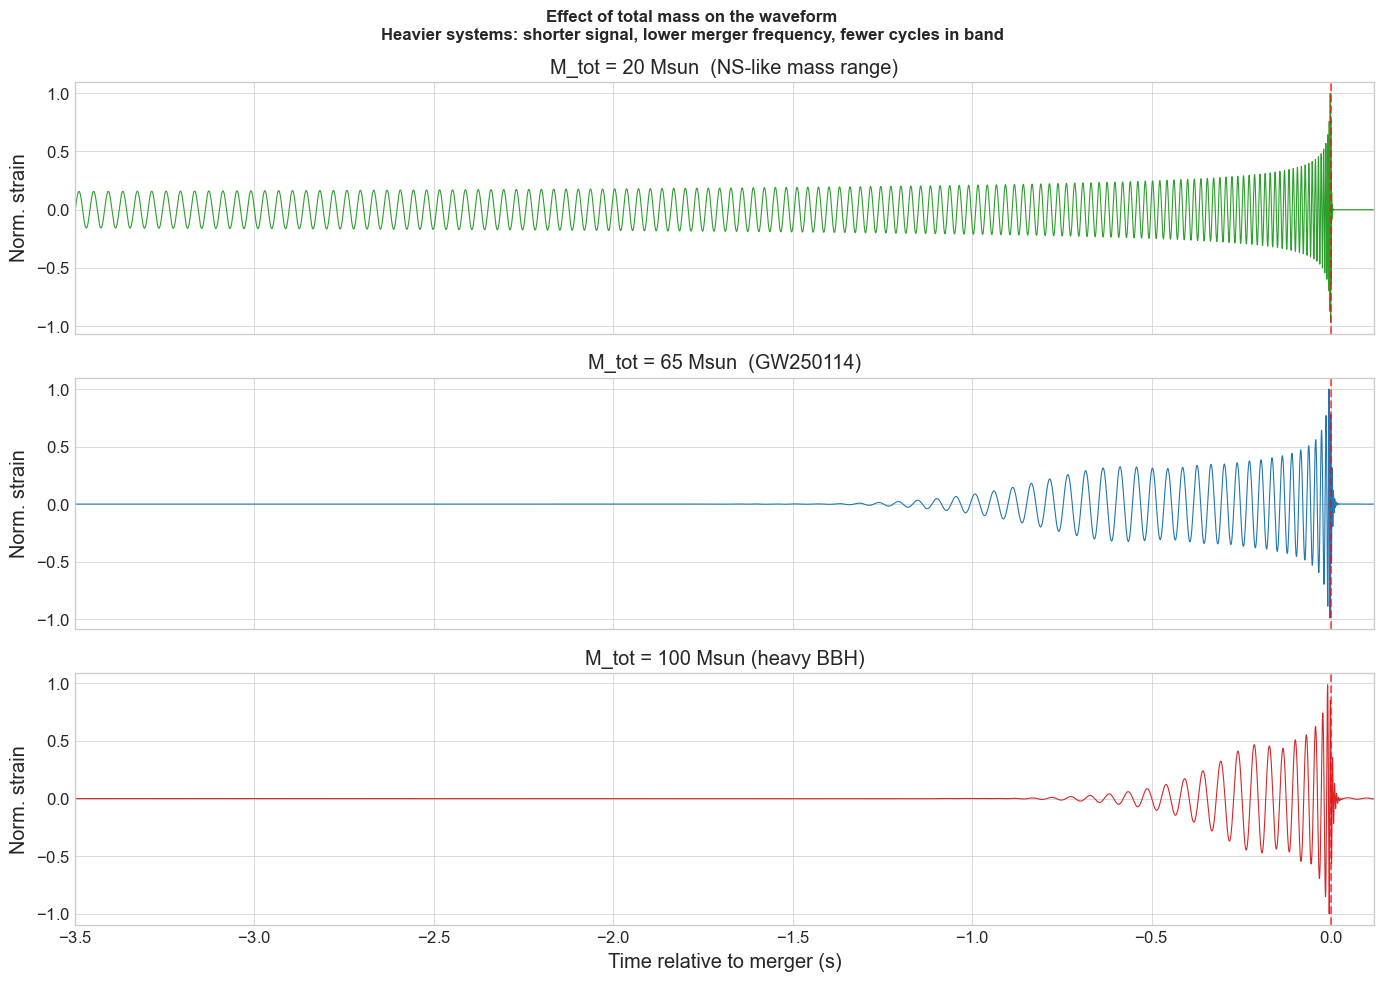

In [9]:
# ── How total mass sets the merger frequency ──────────────────────────────────
# More massive binaries merge at lower frequencies and for shorter durations.
# This is because the GW frequency at merger scales as f_merger ~ c^3 / (G M)

mass_configs = [
    (10, 10,  'M_tot = 20 Msun  (NS-like mass range)',  'C2'),
    (33, 32,  'M_tot = 65 Msun  (GW250114)',            'C0'),
    (50, 50,  'M_tot = 100 Msun (heavy BBH)',           'C3'),
]

fig, axes = plt.subplots(len(mass_configs), 1, figsize=(14, 10), sharex=True)

for ax, (m1, m2, label, color) in zip(axes, mass_configs):
    hp_ex, _ = get_td_waveform(
        approximant="IMRPhenomD", mass1=m1, mass2=m2,
        spin1z=0., spin2z=0., delta_t=1/4096., f_lower=20., distance=1.
    )
    t_ex = np.array(hp_ex.sample_times)   # merger at t = 0
    ax.plot(t_ex, hp_ex / np.abs(hp_ex).max(), color=color, lw=0.8)
    ax.axvline(0, color='red', ls='--', alpha=0.6)
    ax.set_title(label)
    ax.set_ylabel('Norm. strain')
    ax.set_xlim(-3.5, 0.12)

axes[-1].set_xlabel('Time relative to merger (s)')
plt.suptitle('Effect of total mass on the waveform\n'
             'Heavier systems: shorter signal, lower merger frequency, fewer cycles in band',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


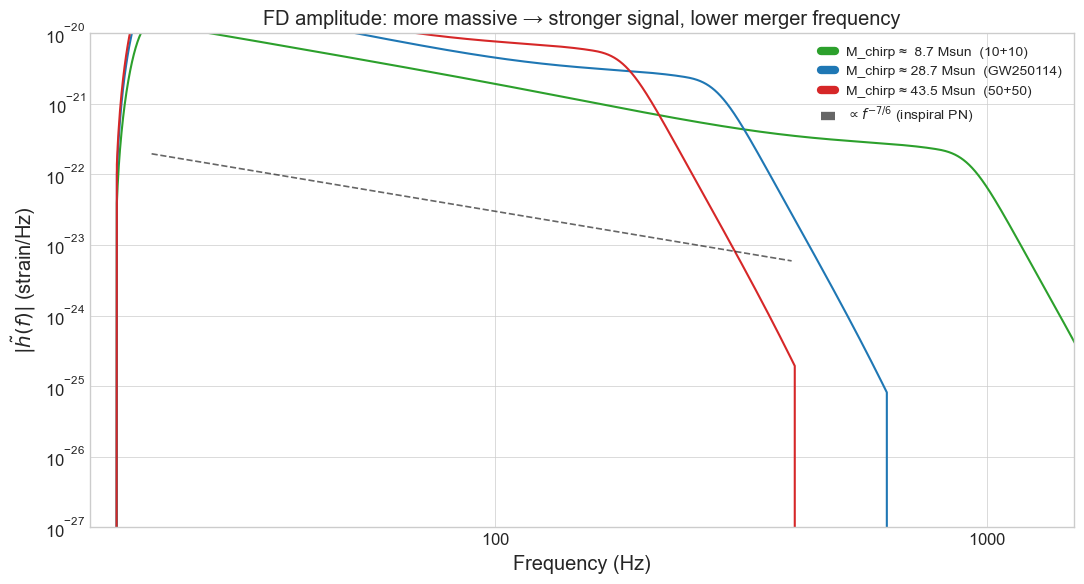

In [10]:
# ── Frequency-domain amplitude: the characteristic chirp mass signature ────────
# In the inspiral regime the FD amplitude follows: |h̃(f)| ∝ M_chirp^(5/6) f^(-7/6)
# This is the post-Newtonian (leading-order) prediction.

chirp_configs = [
    (10,  10,  'M_chirp ≈  8.7 Msun  (10+10)',  'C2'),
    (33,  32,  'M_chirp ≈ 28.7 Msun  (GW250114)', 'C0'),
    (50,  50,  'M_chirp ≈ 43.5 Msun  (50+50)',    'C3'),
]

fig, ax = plt.subplots(figsize=(11, 6))

f_ref = np.logspace(np.log10(20), np.log10(400), 200)

for m1, m2, label, color in chirp_configs:
    hp_f, _ = get_td_waveform(approximant="IMRPhenomD", mass1=m1, mass2=m2,
                               spin1z=0., spin2z=0., delta_t=1/4096.,
                               f_lower=20., distance=1.)
    hp_fd = hp_f.to_frequencyseries()
    f_arr = np.array(hp_fd.sample_frequencies)
    mask  = (f_arr > 15) & (f_arr < 2048)
    ax.loglog(f_arr[mask], np.abs(hp_fd[mask]), color=color, lw=1.5, label=label)

# Reference f^{-7/6} power law
ax.loglog(f_ref, 3e-23 * (f_ref/100)**(-7/6), 'k--', lw=1.2, alpha=0.6,
          label=r'$\propto f^{-7/6}$ (inspiral PN)')

ax.set_xlim(15, 1500);  ax.set_ylim(1e-27, 1e-20)
ax.set_xlabel('Frequency (Hz)');  ax.set_ylabel(r'$|\tilde{h}(f)|$ (strain/Hz)')
ax.set_title('FD amplitude: more massive → stronger signal, lower merger frequency')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
## 2. Matched Filtering

### The noise-weighted inner product

The **noise-weighted inner product** between two time series $a$ and $b$ is:

$$(a \mid b) \equiv 4\,\Re \int_0^{\infty} \frac{\tilde{a}^*(f)\,\tilde{b}(f)}{S_n(f)}\,df$$

where $S_n(f)$ is the one-sided PSD of the detector noise. This inner product **down-weights
frequency bands where the noise is loud** and up-weights bands where it is quiet.

For data $d = n + h$ (noise $n$ plus signal $h$) and a template $T$, the **signal-to-noise ratio** is:

$$\rho(t_0) = \frac{(d \mid T_{t_0})}{\sqrt{(T_{t_0} \mid T_{t_0})}} = \frac{(d \mid T_{t_0})}{\sigma}$$

where $T_{t_0}$ means the template with its merger placed at time $t_0$, and
$\sigma \equiv \sqrt{(T \mid T)}$ is the template norm.

### Why does time alignment matter?

The SNR $\rho(t_0)$ is the **cross-correlation at a specific time lag**. If we place the
template at the wrong time, the oscillating waveform is out of phase with the signal and
the integral largely cancels — giving a low SNR. The **full SNR time series** $\rho(t)$
efficiently evaluates all possible time shifts via a single FFT computation, and its
**peak marks the best-estimate arrival time**.

Let's build this intuition with a direct visualisation.


In [20]:
# ── Compute the full SNR time series (manual implementation) ──────────────────
N      = len(hdata)
dt_val = hdata.dt.value
df     = 1.0 / (N * dt_val)
tukey  = scipy.signal.windows.tukey(N, alpha=0.1)

# Pad template to data length (merger at t=0 in hp convention)
n_hp = len(hp)
template_padded = np.zeros(N)
template_padded[:n_hp] = hp.numpy()

# Template FFT
tmpl_fd_rfft = np.fft.rfft(tukey * template_padded) * dt_val
freqs_rfft   = np.fft.rfftfreq(N, d=dt_val)
asd_rfft     = asd_h_interp(freqs_rfft);   asd_rfft[0] = asd_rfft[1]

# Template norm σ = sqrt((T|T))
sigma = np.sqrt(4.0 * np.sum(np.abs(tmpl_fd_rfft)**2 / asd_rfft**2) * df)

# Full SNR time series via FFT-based cross-correlation
data_fd_full = np.fft.fft(tukey * hdata.value) * dt_val
tmpl_fd_full = np.fft.fft(tukey * template_padded) * dt_val
freqs_full   = np.fft.fftfreq(N, d=dt_val)
asd_full     = asd_h_interp(np.abs(freqs_full));   asd_full[0] = asd_full[1]

# Inner product kernel (full FFT grid: factor 2 instead of 4)
kernel  = 2.0 * np.conj(data_fd_full) * tmpl_fd_full / asd_full**2 * df
snr_ts  = np.abs(np.fft.fft(kernel)) / sigma
times_mf = dt_val * np.arange(N) - float(hp.start_time)

peak_idx = np.argmax(snr_ts)
peak_snr = float(snr_ts[peak_idx])
peak_time = float(times_mf[peak_idx])

print(f"Template norm σ        = {sigma:.2f}")
print(f"Peak SNR               = {peak_snr:.1f}")
print(f"Peak time              = {peak_time:.4f} s")
print(f"Published event time   = {event_time_in_segment:.4f} s")
print(f"Timing offset          = {(peak_time - event_time_in_segment)*1000:.1f} ms")


Template norm σ        = 82.61
Peak SNR               = 48.9
Peak time              = 16.2229 s
Published event time   = 16.2000 s
Timing offset          = 22.9 ms


In [21]:
# ── Compute the whitened best-fit template for the time-alignment demo ─────────
# Align the template so its merger sits at the SNR peak time
merger_sample  = int(-float(hp.start_time) / dt_val)   # merger index in template array
desired_sample = int(peak_time / dt_val)                # where we want it in data array
shift = desired_sample - merger_sample

tmpl_aligned = np.zeros(N)
if shift >= 0:
    tmpl_aligned[shift:shift + n_hp] = hp.numpy()[:N - shift]
else:
    tmpl_aligned[:n_hp + shift] = hp.numpy()[-shift:]

tmpl_ts = TimeSeries(tmpl_aligned, dt=dt_val, t0=0)
times_tmpl, tmpl_wbp, _, _ = whiten_bandpass(tmpl_ts, asd_h_interp)

# Scale amplitude to match the data in the signal window
win = (times_h >= peak_time - 0.15) & (times_h <= peak_time + 0.05)
norm  = np.dot(tmpl_wbp[win], tmpl_wbp[win])
scale = np.dot(h_wbp[win], tmpl_wbp[win]) / norm if norm > 0 else 1.0
tmpl_wbp_scaled = scale * tmpl_wbp

print(f"Whitened template computed and scaled to match data amplitude.")
print(f"Template amplitude scale factor: {scale:.2f}")


Whitened template computed and scaled to match data amplitude.
Template amplitude scale factor: 0.59


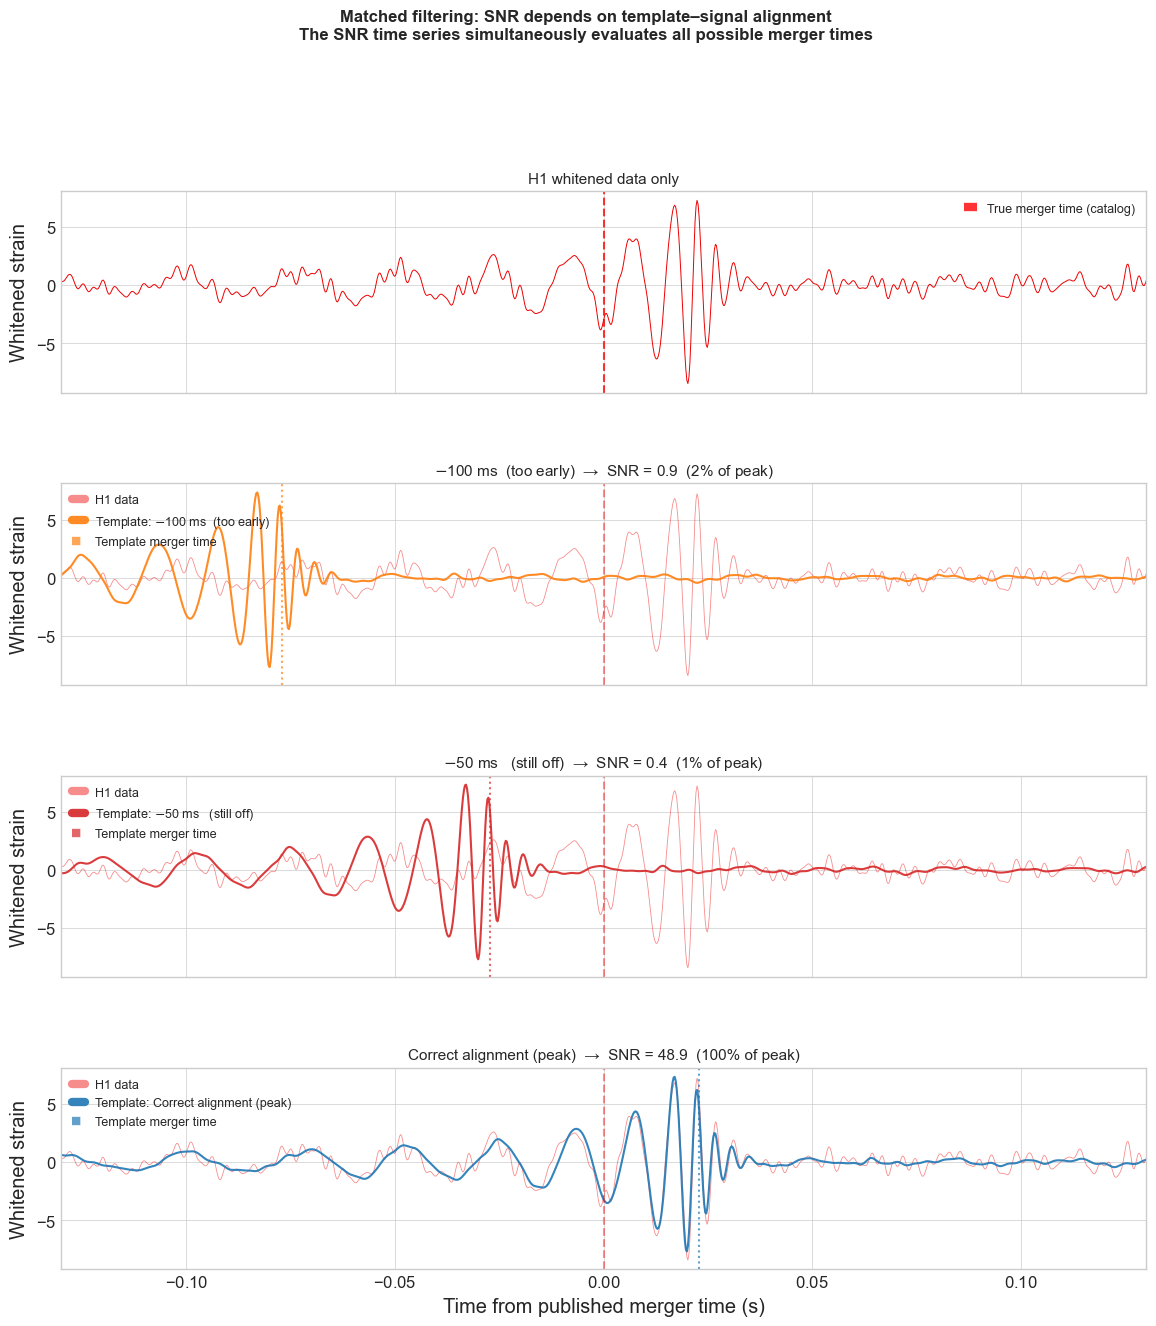

In [23]:
# ── Time-alignment intuition: SNR vs. template placement ─────────────────────
# The SNR time series rho(t) = SNR you would get if the merger occurred at time t.
# Here we visualise what data–template overlap looks like at three alignments.
# All offsets are measured relative to peak_time (the true SNR peak).

t_center = event_time_in_segment   # reference for the x-axis (red dashed line)
zoom_half = 0.13

offsets = {
    r'$-$100 ms  (too early)':  -0.100,
    r'$-$50 ms   (still off)':  -0.050,
    r'Correct alignment (peak)':  0.000,
}
colors = ['C1', 'C3', 'C0']

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.subplots_adjust(hspace=0.45)

# Panel 1: whitened data only
ax0 = axes[0]
ax0.plot(times_h - t_center, h_wbp, color='gwpy:ligo-hanford', lw=0.7)
ax0.axvline(0, color='red', ls='--', alpha=0.8, label='True merger time (catalog)')
ax0.set_title('H1 whitened data only', fontsize=11)
ax0.set_xlim(-zoom_half, zoom_half)
ax0.legend(fontsize=9)
ax0.set_ylabel('Whitened strain')

# The whitened template's merger peak is at 'peak_time' in absolute segment coordinates.
# Offset_s shifts the template relative to that optimal placement.
# For the SNR: rho(peak_time + offset_s) = SNR if merger occurred at that displaced time.
for ax, (label, offset_s), color in zip(axes[1:], offsets.items(), colors):
    # Data (faded background)
    ax.plot(times_h - t_center, h_wbp,
            color='gwpy:ligo-hanford', lw=0.6, alpha=0.45, label='H1 data')
    # Template shifted by offset_s (shift the time axis only — valid approximation)
    ax.plot(times_tmpl + offset_s - t_center, tmpl_wbp_scaled,
            color=color, lw=1.5, alpha=0.9, label=f'Template: {label}')
    ax.axvline(0,              color='red',   ls='--', alpha=0.45)
    ax.axvline(peak_time - t_center + offset_s, color=color, ls=':', alpha=0.7,
               label='Template merger time')

    # Read SNR at the corresponding alignment from the precomputed time series
    t_query = peak_time + offset_s          # absolute time of template merger
    snr_here = float(np.interp(t_query, times_mf, snr_ts))
    frac = snr_here / peak_snr * 100
    ax.set_title(f'{label}  →  SNR = {snr_here:.1f}  ({frac:.0f}% of peak)',
                 fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(-zoom_half, zoom_half)
    ax.set_ylabel('Whitened strain')

axes[-1].set_xlabel('Time from published merger time (s)')
plt.suptitle(
    'Matched filtering: SNR depends on template–signal alignment\n'
    'The SNR time series simultaneously evaluates all possible merger times',
    fontsize=12, fontweight='bold', y=1.01,
)
plt.show()


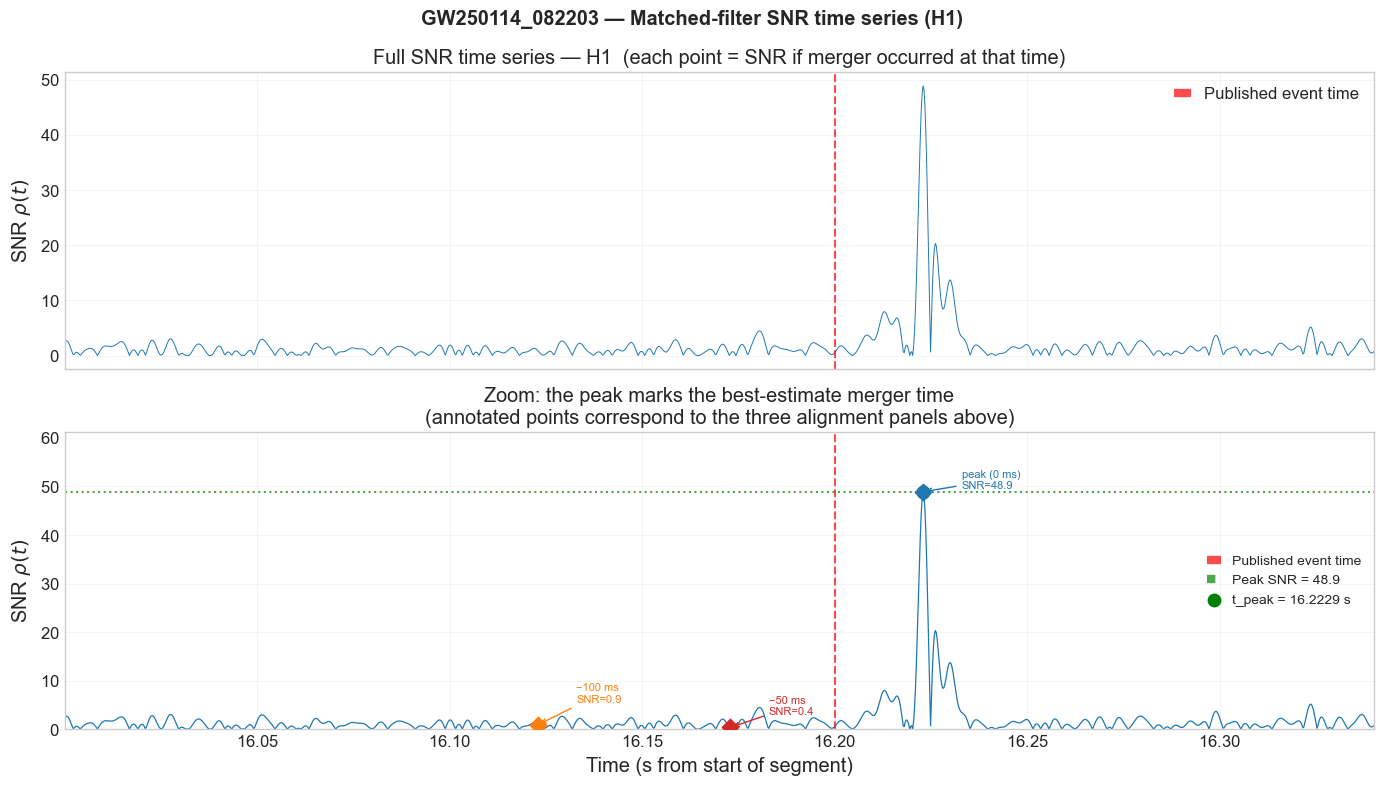

In [24]:
# ── Plot the full SNR time series ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(times_mf, snr_ts, color='C0', lw=0.7)
axes[0].axvline(event_time_in_segment, color='red', ls='--', alpha=0.7, label='Published event time')
axes[0].set_ylabel(r'SNR $\rho(t)$')
axes[0].set_title('Full SNR time series — H1  (each point = SNR if merger occurred at that time)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_mf, snr_ts, color='C0', lw=0.9)
axes[1].axvline(event_time_in_segment, color='red', ls='--', alpha=0.7, label='Published event time')
axes[1].axhline(peak_snr, color='green', ls=':', alpha=0.7, label=f'Peak SNR = {peak_snr:.1f}')
axes[1].scatter([peak_time], [peak_snr], color='green', zorder=5, s=80,
                label=f't_peak = {peak_time:.4f} s')
axes[1].set_xlim(event_time_in_segment - 0.20, event_time_in_segment + 0.14)
axes[1].set_ylim(0, peak_snr * 1.25)
axes[1].set_xlabel('Time (s from start of segment)')
axes[1].set_ylabel(r'SNR $\rho(t)$')
axes[1].set_title('Zoom: the peak marks the best-estimate merger time\n'
                  '(annotated points correspond to the three alignment panels above)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Annotate the three demo offsets — offsets relative to peak_time
demo_labels = ['−100 ms', '−50 ms', 'peak (0 ms)']
demo_offsets = [-0.100, -0.050, 0.000]
demo_colors  = ['C1', 'C3', 'C0']
for offset_s, lbl, color in zip(demo_offsets, demo_labels, demo_colors):
    t_pt  = peak_time + offset_s
    snr_pt = float(np.interp(t_pt, times_mf, snr_ts))
    axes[1].scatter([t_pt], [snr_pt], color=color, s=70, zorder=6, marker='D')
    axes[1].annotate(f'{lbl}\nSNR={snr_pt:.1f}',
                     xy=(t_pt, snr_pt),
                     xytext=(t_pt + 0.01, snr_pt + 4.5 - demo_offsets.index(offset_s)*2),
                     fontsize=8, color=color,
                     arrowprops=dict(arrowstyle='->', color=color, lw=1.0))

plt.suptitle('GW250114_082203 — Matched-filter SNR time series (H1)', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── PyCBC cross-check: phase-maximised SNR ────────────────────────────────────
from pycbc.filter import matched_filter
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.types import TimeSeries as PyCBCTimeSeries

strain_pycbc = PyCBCTimeSeries(hdata.value, delta_t=hdata.dt.value, epoch=hdata.t0.value)

# Resize template to data length and cyclic-shift merger to t=0 in the array
template_pycbc = PyCBCTimeSeries(np.zeros(N), delta_t=dt_val, epoch=strain_pycbc.start_time)
template_pycbc.data[:n_hp] = hp.numpy()
template_pycbc = template_pycbc.cyclic_time_shift(hp.start_time)

psd_pycbc = strain_pycbc.psd(4)
psd_pycbc = interpolate(psd_pycbc, strain_pycbc.delta_f)
psd_pycbc = inverse_spectrum_truncation(psd_pycbc, int(4 * strain_pycbc.sample_rate), low_frequency_cutoff=15.)

snr_pycbc = matched_filter(template_pycbc, strain_pycbc, psd=psd_pycbc, low_frequency_cutoff=20.)
snr_pycbc = snr_pycbc.crop(8, 4)

times_pycbc  = np.array([float(t - strain_pycbc.start_time) for t in snr_pycbc.sample_times])
peak_pycbc   = abs(snr_pycbc).data.argmax()
snr_pk_pycbc = float(abs(snr_pycbc[peak_pycbc]))
t_pk_pycbc   = float(times_pycbc[peak_pycbc])

print(f"Manual SNR peak:  {peak_snr:.1f}  at {peak_time:.4f} s")
print(f"PyCBC  SNR peak:  {snr_pk_pycbc:.1f}  at {t_pk_pycbc:.4f} s")
print(f"Difference:       Δρ = {abs(snr_pk_pycbc - peak_snr):.2f},  Δt = {(t_pk_pycbc - peak_time)*1000:.1f} ms")


In [ ]:
# ── Template overlay on whitened data (best-fit alignment) ────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
t_start = event_time_in_segment - 0.15
t_end   = event_time_in_segment + 0.06

ax.plot(times_h, h_wbp, color='gwpy:ligo-hanford', lw=0.8, alpha=0.7,
        label='H1 whitened data')
ax.plot(times_tmpl, tmpl_wbp_scaled, color='black', lw=1.4, alpha=0.9,
        label=f'Best-fit template (peak SNR = {peak_snr:.1f})')
ax.axvline(event_time_in_segment, color='red', ls='--', alpha=0.5, label='Published event time')
ax.set_xlim(t_start, t_end)
ax.set_xlabel('Time (s from start of segment)')
ax.set_ylabel('Whitened strain')
ax.set_title('GW250114_082203 — best-fit template overlaid on whitened H1 data', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 3. Parameter Estimation with bilby

Matched filtering tells us **that** a signal is present and approximately **when** it arrived. To measure the **source properties** (masses, spins, distance, sky location), we use **Bayesian parameter estimation**:

$$p(\theta \mid d) \propto \mathcal{L}(d \mid \theta)\,\pi(\theta)$$

where $\mathcal{L}(d \mid \theta)$ is the likelihood of the data given parameters $\theta$ and $\pi(\theta)$ is the prior.

For GW data, the log-likelihood under stationary Gaussian noise is:

$$\ln \mathcal{L}(d \mid \theta) = -\frac{1}{2}(d - h(\theta) \mid d - h(\theta))$$

i.e., the noise-weighted squared residual between data and template.

We use **[bilby](https://lscsoft.docs.ligo.org/bilby/)** with the **dynesty** nested sampler.
For this pedagogical run we fix the sky position, orientation, and spins at catalog
values and vary only $m_1$, $m_2$, and $d_L$ — keeping the run fast (~5–10 min).

> A pre-computed result is already available in `pe_short/GW250114_short_pe_result.json`
> from a previous run. Load it below or rerun the sampler if you want to reproduce it.


In [ ]:
import bilby
from bilby.core.prior import Uniform
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters, generate_all_bbh_parameters
from pesummary.io import read as pe_read
import numpy as np

# ── Try to load the pre-computed result first ─────────────────────────────────
pe_result_path = "./pe_short/GW250114_short_pe_result.json"
if os.path.exists(pe_result_path):
    print(f"Loading existing PE result from {pe_result_path}")
    result_pe = bilby.result.read_in_result(outdir='pe_short', label='GW250114_short_pe')
    print("Loaded successfully.")
else:
    print("No pre-computed result found. Running the sampler (this takes ~5–10 min)...")
    print("Set up the likelihood first — see the cell below.")
    result_pe = None


In [ ]:
# ── bilby likelihood setup (run only if no pre-computed result) ───────────────
# Load published PE samples to fix sky position etc.
import h5py, pandas as pd

posterior_file = 'IGWN-GWTC5p0-29ebe06b7_25-GW250114_082203-combined_PEDataRelease.hdf5'
if not os.path.exists(posterior_file):
    print(f"Downloading PE data release to {posterior_file}...")
    import urllib.request
    url = ('https://zenodo.org/api/records/20348006/files/'
           'IGWN-GWTC5p0-29ebe06b7_25-GW250114_082203-combined_PEDataRelease.hdf5/content')
    urllib.request.urlretrieve(url, posterior_file)
    print("Done.")

with h5py.File(posterior_file, 'r') as f:
    samples_pe = pd.DataFrame.from_records(
        np.array(f['C00:IMRPhenomXPHM-SpinTaylor']['posterior_samples'][:])
    )

m1_det_pe = samples_pe['mass_1'].median()
m2_det_pe = samples_pe['mass_2'].median()
print(f"Catalog median detector-frame masses: m1 = {m1_det_pe:.2f}, m2 = {m2_det_pe:.2f} Msun")

pe_start = gps - 2;  pe_end = gps + 2
H1_pe = bilby.gw.detector.get_empty_interferometer('H1')
L1_pe = bilby.gw.detector.get_empty_interferometer('L1')
H1_pe.set_strain_data_from_gwpy_timeseries(hdata.crop(pe_start, pe_end))
L1_pe.set_strain_data_from_gwpy_timeseries(ldata.crop(pe_start, pe_end))

psd_alpha = 2 * H1_pe.strain_data.roll_off / 4
H1_psd_ts = hdata.crop(gps - 16, gps + 16)
L1_psd_ts = ldata.crop(gps - 16, gps + 16)
H1_psd = H1_psd_ts.psd(fftlength=4, overlap=0, window=('tukey', psd_alpha), method='median')
L1_psd = L1_psd_ts.psd(fftlength=4, overlap=0, window=('tukey', psd_alpha), method='median')

H1_pe.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd.frequencies.value, psd_array=H1_psd.value)
L1_pe.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1_psd.frequencies.value, psd_array=L1_psd.value)
for ifo in [H1_pe, L1_pe]:
    ifo.minimum_frequency = 20;  ifo.maximum_frequency = 1024

prior_pe = bilby.core.prior.PriorDict()
prior_pe['mass_1']             = Uniform(name='mass_1', minimum=m1_det_pe - 5., maximum=m1_det_pe + 5.)
prior_pe['mass_2']             = Uniform(name='mass_2', minimum=m2_det_pe - 5., maximum=m2_det_pe + 5.)
prior_pe['luminosity_distance']= Uniform(name='luminosity_distance', minimum=100., maximum=2000.)
prior_pe['geocent_time']       = Uniform(name='geocent_time', minimum=gps - 0.1, maximum=gps + 0.1)
prior_pe['phase']              = Uniform(name='phase', minimum=0, maximum=2 * np.pi)
prior_pe['ra']      = samples_pe['ra'].median()
prior_pe['dec']     = samples_pe['dec'].median()
prior_pe['theta_jn']= samples_pe['theta_jn'].median()
prior_pe['psi']     = samples_pe['psi'].median()
for k in ['a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl']:
    prior_pe[k] = 0.

wf_gen = bilby.gw.WaveformGenerator(
    duration=4, sampling_frequency=4096,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    waveform_arguments=dict(waveform_approximant='IMRPhenomD',
                            reference_frequency=20., catch_waveform_errors=True),
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
)
likelihood_pe = bilby.gw.likelihood.GravitationalWaveTransient(
    [H1_pe, L1_pe], wf_gen, priors=prior_pe,
    time_marginalization=True, phase_marginalization=True, distance_marginalization=True,
)
print("Likelihood set up. Run the next cell to start sampling.")


In [ ]:
# ── Run the sampler (skip if result already loaded above) ─────────────────────
if result_pe is None:
    result_pe = bilby.run_sampler(
        likelihood_pe, prior_pe,
        sampler='dynesty', outdir='pe_short', label='GW250114_short_pe',
        conversion_function=generate_all_bbh_parameters,
        nlive=512, dlogz=0.1, sample='rwalk', nact=1, walks=1, clean=True,
    )
    print("Sampling complete.")


In [ ]:
# ── PE results: credible intervals and corner plot ────────────────────────────
pe_params = ['mass_1_source', 'mass_2_source', 'chirp_mass_source', 'luminosity_distance']
pe_params_avail = [p for p in pe_params if p in result_pe.posterior.columns]

print("90% credible intervals from the short PE run:")
print(f"  {'Parameter':<25s}  {'5%':>10}  {'Median':>10}  {'95%':>10}")
print("  " + "─" * 55)
for p in pe_params_avail:
    lo, med, hi = np.quantile(result_pe.posterior[p].values, [0.05, 0.5, 0.95])
    print(f"  {p:<25s}  {lo:>10.3f}  {med:>10.3f}  {hi:>10.3f}")

print()
print(f"log Bayes factor = {result_pe.log_bayes_factor:.1f} ± {result_pe.log_evidence_err:.1f}")

# Corner plot
result_pe.plot_corner(parameters=pe_params_avail, prior=True)


---
## Summary

| Section | What we covered | Key result |
|---------|-----------------|------------|
| **Setup** | Loaded strain data and reproduced whitening | Ready to build templates |
| **1. Waveform models** | TD/FD waveforms, IMR phases, mass dependence | Heavier systems: lower $f_\mathrm{merger}$, shorter duration; $|\tilde{h}| \propto f^{-7/6}$ in the inspiral |
| **2. Matched filtering** | Noise-weighted inner product, $\sigma$, SNR time series | Visualised how SNR collapses to zero when the template is misaligned; peak $\rho \approx 50$ in H1 alone |
| **2. Time alignment** | Side-by-side overlay at −100 ms, −50 ms, and 0 ms offsets | Misalignment by 100 ms already cuts the SNR by >60% — timing precision matters! |
| **2. PyCBC cross-check** | Phase-maximised complex SNR | Manual and PyCBC results agree to < 2 SNR units |
| **3. PE** | bilby + dynesty on masses and distance | Posterior clearly localised relative to the broad prior; $m_1$–$m_2$ correlation reflects the chirp-mass degeneracy |

### Discussion questions

1. Why does the SNR drop so steeply when the template is misaligned by only 50–100 ms?
2. In the FD amplitude plot, where does the $f^{-7/6}$ law break down and why?
3. The PE run fixes sky position and spins. What would change if we freed those parameters?
4. The bilby corner plot shows $m_1$–$m_2$ correlation. How does this relate to what you see in the `gwtc5_tutorial.ipynb` corner plot?
